In [1]:
!pip install numpy matplotlib graphviz
%load_ext autoreload
%autoreload 2

In [2]:

from dataclasses import dataclass
import numpy as np
from typing import Any, List, Callable
from collections import defaultdict
from mdp import Policy, MDP, Step, value_evaluation, Rollout, FlackyTramMDP

class DiceGameMDP(MDP):
    def start_state(self) -> str:
        return "in"

    def is_end(self, state: str) -> bool:
        return state == "end"
    
    def discount(self) -> float:
        return 1

    def successors(self, state: str) -> List[Step]:
        if state == 'end':
            return []
        return [
            Step(action="quit", reward=10.0, prob=1, state="end"),
            Step(action="stay", reward=4.0, prob=1/3, state="end"),
            Step(action="stay", reward=4.0, prob=2/3, state="in")
        ]


In [3]:
# ============= Monte Carlo Policy Evaluation ================
# Run multiple rollouts with the policy and compute average utility

def generate_rollout(mdp: MDP, policy: Policy) -> Rollout:
    state = mdp.start_state()
    steps = []
    while not mdp.is_end(state):
        action = policy(state)
        successors = [step for step in mdp.successors(state) if step.action == action]
        probs = [step.prob for step in successors]
        choice = np.random.choice(len(successors), p=probs)
        step = successors[choice]
        steps.append(step)
        state = step.state
    return Rollout(
        steps=steps, 
        discount=mdp.discount())

def monte_carlo_policy_evaluation(mdp: MDP, policy: Policy, num_rollouts: int) -> float:
    utilities = [generate_rollout(mdp, policy).utility for _ in range(num_rollouts)]
    return float(np.mean(utilities))

# Test monte carlo policy evaluation
tram_mdp = FlackyTramMDP(num_locs=10, failure_prob=0.4)
walk_policy = lambda s: "walk"
tram_policy = lambda s: "tram" if s * 2 <= tram_mdp.num_locs else "walk"
walk_eval = monte_carlo_policy_evaluation(tram_mdp, walk_policy, 1)
tram_eval = monte_carlo_policy_evaluation(tram_mdp, tram_policy, 100)
print("walk:", walk_eval, "tram: ", tram_eval, "discount:", tram_mdp.discount())

walk: -6.12579511 tram:  -9.402841364743939 discount: 0.9


{1: -9.127740422222459, 2: -7.1143556447217735, 3: -6.026656281067523, 4: -4.728125004960195, 5: -3.1250000007830225, 6: -3.439, 7: -2.71, 8: -1.9, 9: -1.0, 10: 0}


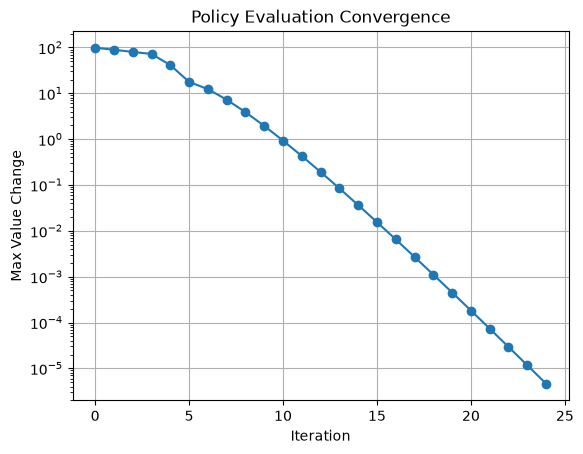

In [4]:
import matplotlib.pyplot as plt
from mdp import get_states, initial_values, compute_q_value, compute_distance

#=============== Policy Evaluation w/o Rollout =========================

def policy_evaluation(mdp: MDP, policy: Policy, max_iters: int =100, tolerance: float = 1e-5) -> tuple[dict[Any, float], List[float]]:
    states = get_states(mdp)
    values = initial_values(mdp, states)
    distances = []
    for _ in range(max_iters):
        next_values = {}
        for state in states:
            if mdp.is_end(state):
                next_values[state] = 0
                continue
            action = policy(state)
            steps = [step for step in mdp.successors(state) if step.action == action]
            next_values[state] = compute_q_value(values, steps, mdp.discount())
        distance = compute_distance(values, next_values)
        distances.append(distance)
        values = next_values
        if distance < tolerance:
            break
    return values, distances

def draw_evaluation_convergence(distances: List[float]):
    plt.plot(distances, marker='o')
    plt.title("Policy Evaluation Convergence")
    plt.xlabel("Iteration")
    plt.ylabel("Max Value Change")
    plt.yscale('log')
    plt.grid(True)
    plt.show()

# Test and draw converge diagram
values, distances = policy_evaluation(tram_mdp, tram_policy)
#values, distances = policy_evaluation(tram_mdp, walk_policy)
print(values)
draw_evaluation_convergence(distances)



{1: -7.3333399762160845, 2: -6.333335990486434, 3: -5.333334396194574, 4: -4.3333337584778295, 5: -3.333333503391132, 6: -4.0, 7: -3.0, 8: -2.0, 9: -1.0, 10: 0}
{1: 'walk', 2: 'walk', 3: 'walk', 4: 'walk', 5: 'tram', 6: 'walk', 7: 'walk', 8: 'walk', 9: 'walk', 10: None}
[99.0, 98.0, 97.0, 96.0, 27.28, 19.520000000000003, 9.280000000000003, 3.7120000000000015, 1.4848, 0.5939199999999998, 0.23756800000000045, 0.09502719999999965, 0.03801087999999986, 0.015204352000000476, 0.006081740800000013, 0.00243269631999965, 0.0009730785280002152, 0.0003892314111997308, 0.00015569256447989233, 6.22770257923122e-05, 2.4910810316747245e-05, 9.964324126698898e-06]


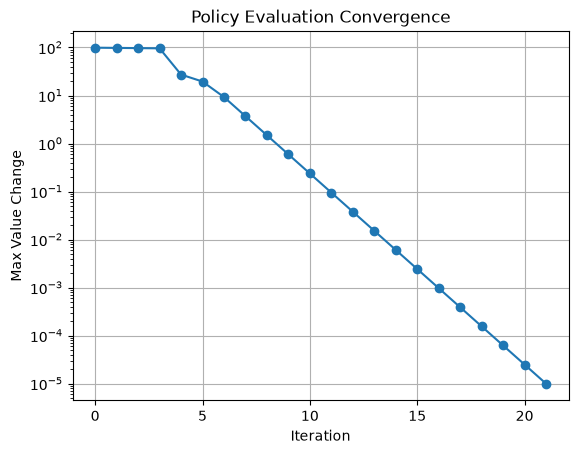

In [ ]:
from mdp import value_evaluation

#=============== Value Evaluation for Optimal Policy =========================

# Test value evaluation
result = value_evaluation(tram_mdp)
print(result.values)
print(result.pi)
print(result.distances)
draw_evaluation_convergence(distances)


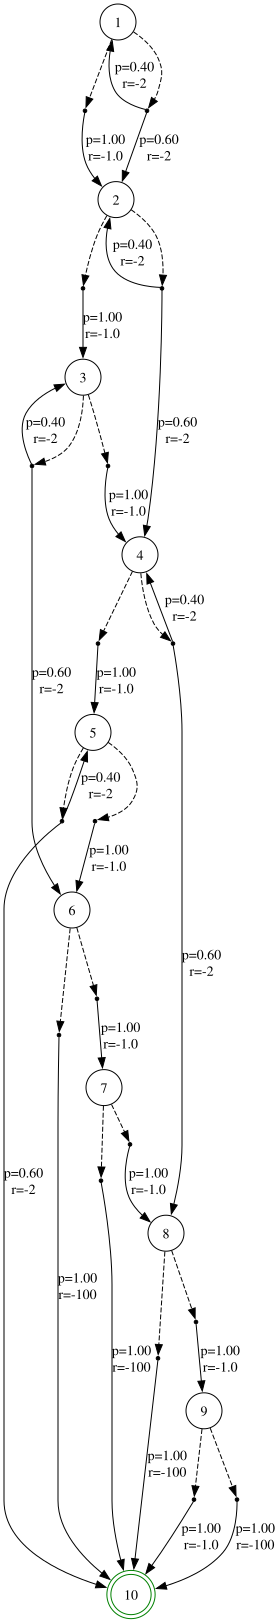

In [5]:
from mdp import draw_mdp_graph

draw_mdp_graph(tram_mdp)